## Гига М.Я. М8О-313Б-23

In [1]:
from typing import List, Tuple, cast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, KFold, cross_val_score
import os
import seaborn as sns
from scipy import stats
import scipy
from scipy.stats import norm, skew
from scipy.special import inv_boxcox
from sklearn.mixture import GaussianMixture
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures

pd.options.display.max_columns = None
epsilon = 1e-6

Преобразуем dataframe, убираем nan, убираем некорректные значения

In [ ]:
df: pd.DataFrame = pd.read_csv("./data/train.csv")
df = df[~df['RiskScore'].isna()]
df = cast(pd.DataFrame, df[df['RiskScore'].abs() < 200])
df.head()  # pyright: ignore[reportUnusedExpression]

In [2]:
# numerical_data = df[df.select_dtypes(include=np.number).columns]
# plt.figure(figsize=(10, 8))
# sns.heatmap(numerical_data.corr(), annot=False, cmap='viridis')

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,0.151985,2.0,1.0,0.168542,0.0,Education,0.0,23.0,5.0,2539.0,247.0,50072.0,15005.0,5569.083333,0.908289,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,0.175693,3.0,0.0,0.141553,0.0,Home,0.0,27.0,11.0,844.0,694.0,91878.0,64877.0,14345.583333,0.797339,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,0.444605,3.0,0.0,0.030987,1.0,Education,0.0,21.0,12.0,12756.0,651.0,292300.0,13918.0,25000.000000,0.915945,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,0.188452,7.0,0.0,0.379843,0.0,Debt Consolidation,0.0,27.0,21.0,1524.0,529.0,13070.0,3846.0,2890.250000,0.876416,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,0.273431,3.0,1.0,0.068659,0.0,Debt Consolidation,0.0,35.0,9.0,1973.0,128.0,33357.0,351603.0,25000.000000,0.888689,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,31.347091


In [3]:
def preprocess(X_in: pd.DataFrame) -> pd.DataFrame:
    X = X_in.copy()
    
    X = X.drop(columns=["ApplicationDate", "AnnualIncome"])
    categorical = X.select_dtypes(include=['object']).columns
    numerical = X.select_dtypes(include=[np.number]).columns


    for col in numerical:
        if X[col].isnull().sum() == 0:
            continue
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)

    for col in categorical:
        if X[col].isnull().sum() == 0:
            continue
        mode_val = X[col].mode()[0]
        X[col].fillna(mode_val, inplace=True)



    X['Income_to_Loan'] = X['MonthlyIncome'] / (X['LoanAmount'] + epsilon)
    X['Income_Debt_Ratio'] = X['MonthlyIncome'] / (X['MonthlyDebtPayments'] + epsilon)
    X['Assets_Liabilities_Ratio'] = X['TotalAssets'] / (X['TotalLiabilities'] + epsilon)
    X['NetWorth_Income'] = X['NetWorth'] / (X['MonthlyIncome'] + epsilon)
    X['Savings_Checking'] = X['SavingsAccountBalance'] + X['CheckingAccountBalance']
    X['Payment_Income_Ratio'] = X['MonthlyLoanPayment'] / (X['MonthlyIncome'] + epsilon)
    X['MonthlyIncome_Loan_Ratio'] = X['MonthlyIncome'] / (X['LoanAmount'] + epsilon)
    X['Assets_Income_Ratio'] = X['TotalAssets'] / (X['MonthlyIncome'] + epsilon)
    X['NetWorth_Loan_Ratio'] = X['NetWorth'] / (X['LoanAmount'] + epsilon)
    X['NetWorth_Loan_Ratio'] = X['NetWorth'] / (X['LoanAmount'] + epsilon)
    X['Debt_Loan_Ratio'] = X['MonthlyDebtPayments'] / (X['LoanAmount'] + epsilon)
    X['Savings_Loan_Ratio'] = X['SavingsAccountBalance'] / (X['LoanAmount'] + epsilon)
    X['Checking_Income_Ratio'] = X['CheckingAccountBalance'] / (X['MonthlyIncome'] + epsilon)
    X['Liabilities_Income_Ratio'] = X['TotalLiabilities'] / (X['MonthlyIncome'] + epsilon)
    X['Income_sqrt'] = np.sqrt(X['MonthlyIncome'])
    X['Loan_sqrt'] = np.sqrt(X['LoanAmount'])
    X['Assets_sqrt'] = np.sqrt(X['TotalAssets'])

    tosquare = ['Age',  'CreditScore', 'LoanAmount',
                     'DebtToIncomeRatio', 'CreditCardUtilizationRate',
                     'MonthlyIncome', 'MonthlyDebtPayments']

    tolog = ['CreditScore', 'DebtToIncomeRatio', 'Age', 'CreditCardUtilizationRate']

    tocube = ['CreditScore', 'DebtToIncomeRatio', 'Age']
    for col in tocube:
        X[f'{col}_cubed'] = X[col] ** 3

    for col in tolog:
        X[f'{col}_logged'] = np.log1p(X[col])

    for col in tosquare:
        X[f'{col}_squared'] = X[col] ** 2

    numerical_new = X.select_dtypes(include=[np.number]).columns.tolist()
    numerical_new = [col for col in numerical_new if col not in numerical]

    poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)

    poly_features = poly.fit_transform(X[numerical])
    poly_vals = pd.DataFrame(
        poly_features,
        columns=poly.get_feature_names_out(numerical),
        index=X.index
    )

    X = pd.concat([X[categorical], X[numerical_new], poly_vals], axis=1)

    return X


y = df['RiskScore']
X = df.drop(columns=['RiskScore'])

X_eng = preprocess(X)
categorical = X_eng.select_dtypes(include=['object']).columns
numerical = X_eng.select_dtypes(include=[np.number]).columns
for col in X_eng.columns:
    cnt = X_eng[col].isna().sum()
    if cnt > 0:
        print(col, cnt)
X_eng.head()

<Axes: >

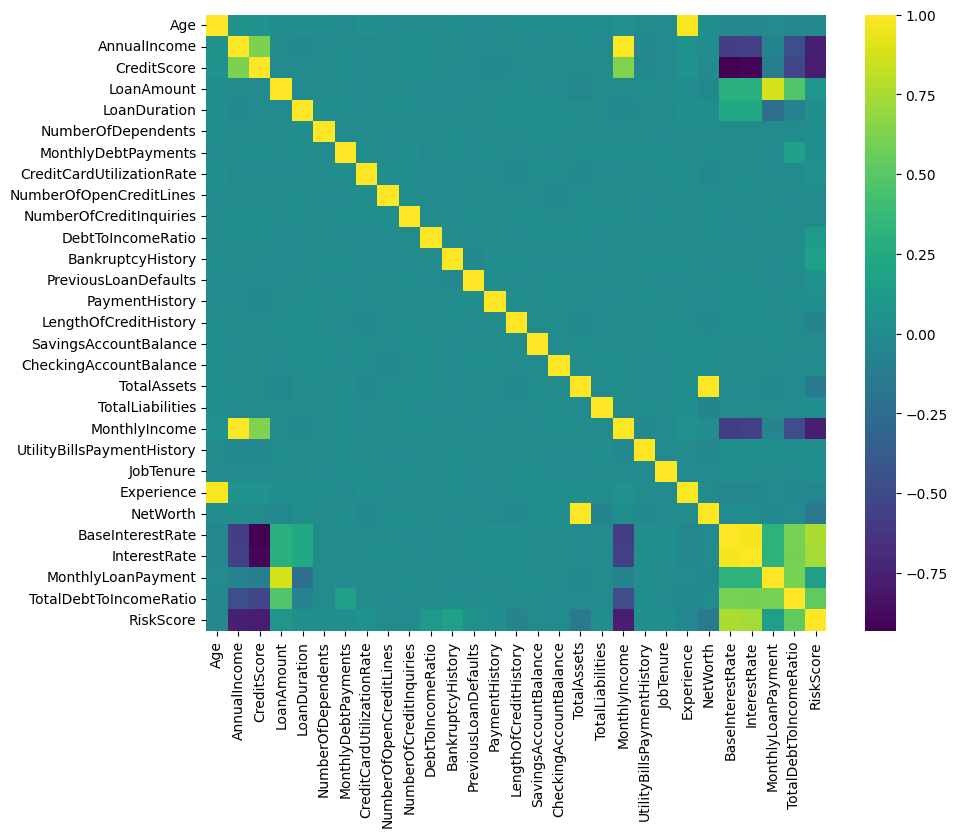

In [10]:
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical),
        ('cat', categorical_transformer, categorical)
    ])


pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [5]:
mse = []

kf = KFold(n_splits=8, shuffle=True, random_state=42)
for train_index, test_index in kf.split(X_eng, y):
    pipeline.fit(X_eng.iloc[train_index], y.iloc[train_index])
    y_pred = pipeline.predict(X_eng.iloc[test_index])
    y_test = y.iloc[test_index]
    mse.append(mean_squared_error(y_test, y_pred))

    print(f"MSE  = {mean_squared_error(y_test, y_pred)}")

mse = np.average(mse)

,MaritalStatus,HomeOwnershipStatus,LoanPurpose,EmploymentStatus,EducationLevel,Income_to_Loan,Income_Debt_Ratio,Assets_Liabilities_Ratio,NetWorth_Income,Savings_Checking,Payment_Income_Ratio,MonthlyIncome_Loan_Ratio,Assets_Income_Ratio,NetWorth_Loan_Ratio,Debt_Loan_Ratio,Savings_Loan_Ratio,Checking_Income_Ratio,Liabilities_Income_Ratio,Income_sqrt,Loan_sqrt,Assets_sqrt,CreditScore_cubed,DebtToIncomeRatio_cubed,Age_cubed,CreditScore_logged,DebtToIncomeRatio_logged,Age_logged,CreditCardUtilizationRate_logged,Age_squared,AnnualIncome_squared,CreditScore_squared,LoanAmount_squared,DebtToIncomeRatio_squared,CreditCardUtilizationRate_squared,MonthlyIncome_squared,MonthlyDebtPayments_squared,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,Age AnnualIncome,Age CreditScore,Age LoanAmount,Age LoanDuration,Age NumberOfDependents,Age MonthlyDebtPayments,Age CreditCardUtilizationRate,Age NumberOfOpenCreditLines,Age NumberOfCreditInquiries,Age DebtToIncomeRatio,Age BankruptcyHistory,Age PreviousLoanDefaults,Age PaymentHistory,Age LengthOfCreditHistory,Age SavingsAccountBalance,Age CheckingAccountBalance,Age TotalAssets,Age TotalLiabilities,Age MonthlyIncome,Age UtilityBillsPaymentHistory,Age JobTenure,Age Experience,Age NetWorth,Age BaseInterestRate,Age InterestRate,Age MonthlyLoanPayment,Age TotalDebtToIncomeRatio,AnnualIncome CreditScore,AnnualIncome LoanAmount,AnnualIncome LoanDuration,AnnualIncome NumberOfDependents,AnnualIncome MonthlyDebtPayments,AnnualIncome CreditCardUtilizationRate,AnnualIncome NumberOfOpenCreditLines,AnnualIncome NumberOfCreditInquiries,AnnualIncome DebtToIncomeRatio,AnnualIncome BankruptcyHistory,AnnualIncome PreviousLoanDefaults,AnnualIncome PaymentHistory,AnnualIncome LengthOfCreditHistory,AnnualIncome SavingsAccountBalance,AnnualIncome CheckingAccountBalance,AnnualIncome TotalAssets,AnnualIncome TotalLiabilities,AnnualIncome MonthlyIncome,AnnualIncome UtilityBillsPaymentHistory,AnnualIncome JobTenure,AnnualIncome Experience,AnnualIncome NetWorth,AnnualIncome BaseInterestRate,AnnualIncome InterestRate,AnnualIncome MonthlyLoanPayment,AnnualIncome TotalDebtToIncomeRatio,CreditScore LoanAmount,CreditScore LoanDuration,CreditScore NumberOfDependents,CreditScore MonthlyDebtPayments,CreditScore CreditCardUtilizationRate,CreditScore NumberOfOpenCreditLines,CreditScore NumberOfCreditInquiries,CreditScore DebtToIncomeRatio,CreditScore BankruptcyHistory,CreditScore PreviousLoanDefaults,CreditScore PaymentHistory,CreditScore LengthOfCreditHistory,CreditScore SavingsAccountBalance,CreditScore CheckingAccountBalance,CreditScore TotalAssets,CreditScore TotalLiabilities,CreditScore MonthlyIncome,CreditScore UtilityBillsPaymentHistory,CreditScore JobTenure,CreditScore Experience,CreditScore NetWorth,CreditScore BaseInterestRate,CreditScore InterestRate,CreditScore MonthlyLoanPayment,CreditScore TotalDebtToIncomeRatio,LoanAmount LoanDuration,LoanAmount NumberOfDependents,LoanAmount MonthlyDebtPayments,LoanAmount CreditCardUtilizationRate,LoanAmount NumberOfOpenCreditLines,LoanAmount NumberOfCreditInquiries,LoanAmount DebtToIncomeRatio,LoanAmount BankruptcyHistory,LoanAmount PreviousLoanDefaults,LoanAmount PaymentHistory,LoanAmount LengthOfCreditHistory,LoanAmount SavingsAccountBalance,LoanAmount CheckingAccountBalance,LoanAmount TotalAssets,LoanAmount TotalLiabilities,LoanAmount MonthlyIncome,LoanAmount UtilityBillsPaymentHistory,LoanAmount JobTenure,LoanAmount Experience,LoanAmount NetWorth,LoanAmount BaseInterestRate,LoanAmount InterestRate,LoanAmount MonthlyLoanPayment,LoanAmount TotalDebtToIncomeRatio,L

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_eng, y, test_size=0.33, random_state=42)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
plt.text(0.1, 0.1, f"MSE  = {mse}", fontsize=10, transform=plt.gca().transAxes)
plt.hist(y_test, bins=30, alpha=0.5, label='Actual', density=True)
plt.hist(y_pred, bins=30, alpha=0.5, label='Predicted', density=True)
plt.legend()
plt.show()

In [ ]:
pipeline.fit(X_eng, y)
path = "./out.csv"
X_valid = pd.read_csv("./data/test.csv")
X_valid = X_valid.drop(columns=["ID"])
X_valid = preprocess(X_valid)

y_valid = pipeline.predict(X_valid)
res = pd.DataFrame()
res["ID"] = np.arange(len(y_valid))
res["RiskScore"] = y_valid
res.set_index("ID", inplace=True)

os.remove("./out.csv")
res.to_csv("./out.csv")
print("written")